# OscillatingString01

Program calculates the oscillation of a continuous string using finite differences.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Parameters

In [2]:
L = 0.1                 # Length of the string in m
rho = 1150              # Linear mass density in kg/m
Phi = 3e9               # Elastic (line) modulus

NG = 1001               # Grid points in space
dx = L/(NG-1)           # Distance between two grid points
mNG = (NG+1)/2          # Center of the spatial axis

Tmax = 0.00004;         # Maximum time
NT = 100001;            # Number of time steps
dt = Tmax/(NT-1);       # Time step size

## Prepare Grids

In [3]:
# Create coordinates for all grid points (1D array)
x = np.arange(NG)*dx    # Spatial grid

# Determine time at all grid points (1D array)
t = np.arange(NT)*dt    # Time grid

# prepare grid
y = np.zeros((NT,NG))

## Initial Conditions

In [4]:
# Initial conditions
y[0, :] = np.sin(3*np.pi*x/L)

# Time step required for a 2nd-order differential equation, set equal to the first one to capture maximum displacement
y[1,:] = y[0,:]

## Solve the PDE

In [5]:
# Solve the PDE using the finite-difference method
for j in range(2,NT):
    for i in range(1, NG-1):
        yx2 = y[j-1,i-1]-2*y[j-1,i]+y[j-1,i+1]
        y[j,i] =2*y[j-1,i]-y[j-2,i]+Phi/rho * (dt/dx)**2 * yx2 

## Visualization

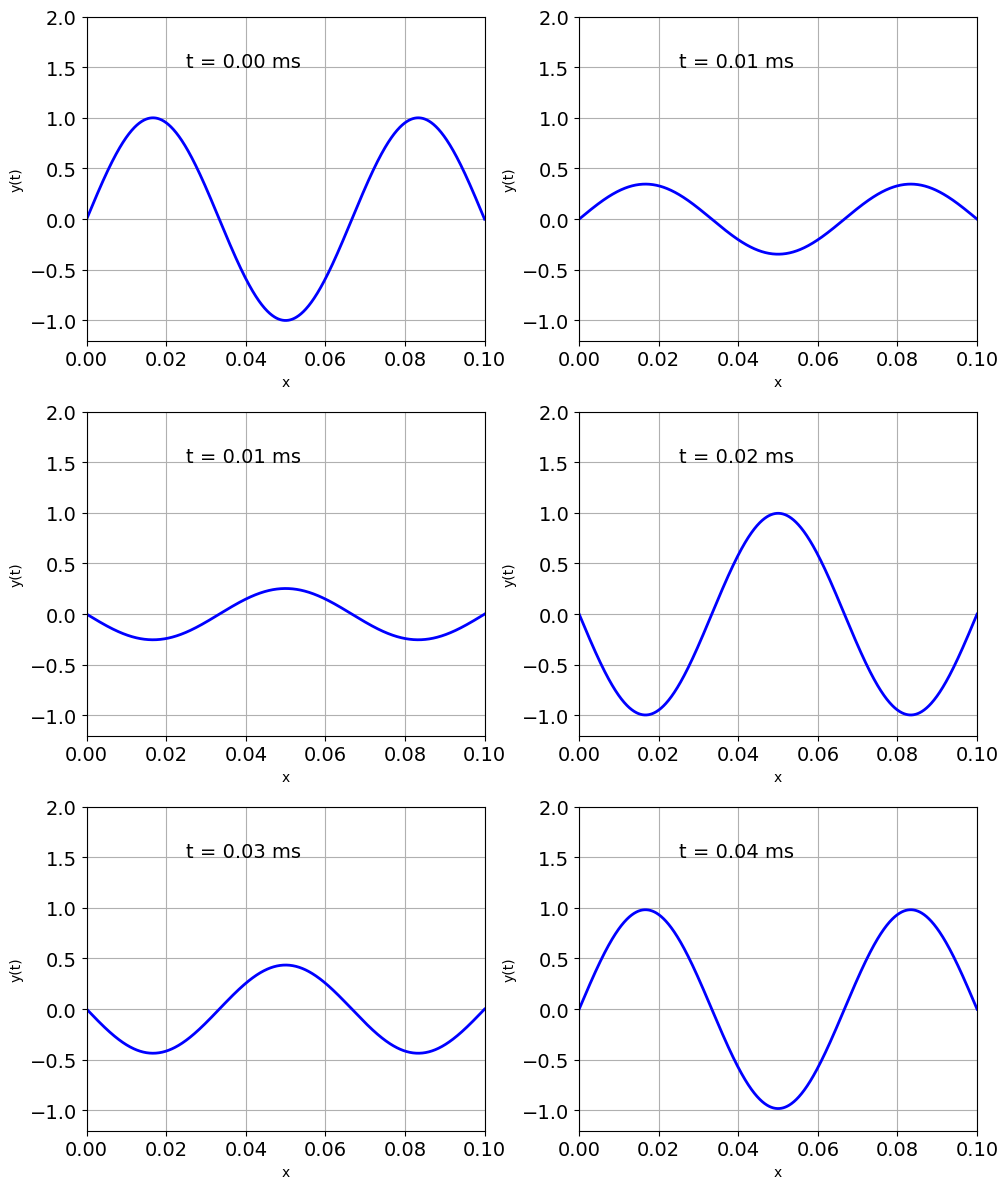

In [6]:
# Visualization of the results
k = [0, 19999, 29999, 49999, 69999, 100000]

fig, axes = plt.subplots(3, 2, figsize=(10,12));

for idx, ax in enumerate(axes.flat):
    j = k[idx]

    ax.plot(x, y[j, :], linewidth=2, color='blue')
    
    ax.grid(True)
    ax.set_xlim([np.min(x), np.max(x)]) 
    ax.set_ylim([-1.2, 2])
    ax.set_xlabel("x")
    ax.set_ylabel("y(t)")
    titletext = "t = %.2f ms" % (t[j] * 1000) 
    ax.text(L/4, 1.5, titletext, fontsize=14)
    ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()